In [188]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

In [189]:
# Load the dataset
df = pd.read_csv("iris.csv")
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [190]:
# Data Preprocessing

X = df.drop("Species", axis=1).values
y = df["Species"].values

label_encoder = LabelEncoder()
y=label_encoder.fit_transform(y)

y = to_categorical(y)

In [191]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [192]:
# Feature Scaling

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [193]:
#Building ANN

model = Sequential()
model.add(Dense(8, activation="relu", input_shape=(X_train.shape[1],)))
model.add(Dense(8, activation="relu"))
model.add(Dense(3, activation="softmax"))

/home/ahn/Documents/Practice/C-Practice/Codes/DL/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [194]:
# Compiling ANN

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [195]:
# Training ANN
history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_test, y_test)
)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.4000 - loss: 1.2440 - val_accuracy: 0.3667 - val_loss: 1.2688
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4083 - loss: 1.2145 - val_accuracy: 0.3667 - val_loss: 1.2330
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4250 - loss: 1.1839 - val_accuracy: 0.3667 - val_loss: 1.1996
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4250 - loss: 1.1549 - val_accuracy: 0.3667 - val_loss: 1.1675
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4333 - loss: 1.1286 - val_accuracy: 0.3667 - val_loss: 1.1365
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4333 - loss: 1.1031 - val_accuracy: 0.3667 - val_loss: 1.1070
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4333 - loss: 1.0784 - val_accuracy: 0.4000 - val_loss: 1.0789
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4417 - loss: 1.0560 - val_accuracy: 0.4000 - val_loss: 1.0521


In [196]:
#Evaluating the ANN
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9333 - loss: 0.4059
Test Loss: 0.4059, Test Accuracy: 0.9333


In [197]:
#Predictions & Matrix

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
print(cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.78      0.88         9
           2       0.85      1.00      0.92        11

    accuracy                           0.93        30
   macro avg       0.95      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

[[10  0  0]
 [ 0  7  2]
 [ 0  0 11]]


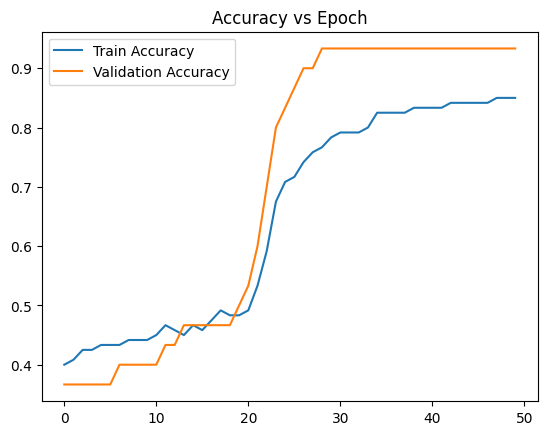

In [198]:
# Accuracy Graph

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy vs Epoch")
plt.show()

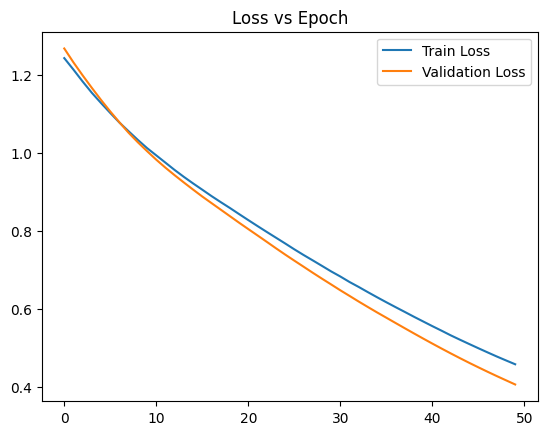

In [199]:
#Loss Graph
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss vs Epoch")
plt.show()